In [3]:
print("Hoangha")

Hoangha


## Preparing a dataset for instruction  fine-tuning

In [4]:
import json
import os
import urllib.request


def download_and_load_file(file_path, url):
    if not os.path.exists(file_path):
        with urllib.request.urlopen(url) as response:
            text_data = response.read().decode("utf-8")

        with open(file_path, "w", encoding="utf-8") as file:
            file.write(text_data)
    else:
        with open(file_path, "r", encoding="utf-8") as file:
            text_data = file.read()

    data = json.loads(text_data)
    return data


file_path = "instruction-data.json"

url = (
    "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch"
    "/main/ch07/01_main-chapter-code/instruction-data.json"
)

data = download_and_load_file(file_path, url)

print("Number of entries:", len(data))

Number of entries: 1100


In [5]:
print("Example entry: \n", data[50])

Example entry: 
 {'instruction': 'Identify the correct spelling of the following word.', 'input': 'Ocassion', 'output': "The correct spelling is 'Occasion.'"}


In [6]:
print("Another example entry:\n", data[999])


Another example entry:
 {'instruction': "What is an antonym of 'complicated'?", 'input': '', 'output': "An antonym of 'complicated' is 'simple'."}


In [7]:
def format_input(entry): 
    instruction_text = (
        f"Below is an instruction that describes a task. "
        f"Write a response that appropriately completes the request. "
        f"\n\n### Instruction:\n{entry['instruction']}"
    )

    input_text = (
        f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""
    )

    return instruction_text + input_text

In [8]:
model_input = format_input(data[50])
desired_response =  f"\n\n### Response:\n{data[50]['output']}"
print(model_input + desired_response)

Below is an instruction that describes a task. Write a response that appropriately completes the request. 

### Instruction:
Identify the correct spelling of the following word.

### Input:
Ocassion

### Response:
The correct spelling is 'Occasion.'


In [9]:
model_input = format_input(data[999])
desired_response = f"\n\n### Response:\n{data[999]['output']}"
print(model_input + desired_response)

Below is an instruction that describes a task. Write a response that appropriately completes the request. 

### Instruction:
What is an antonym of 'complicated'?

### Response:
An antonym of 'complicated' is 'simple'.


### Split dataset

In [10]:
train_portion = int(len(data)*0.85)
test_portion = int(len(data)*0.1)
val_portion = len(data) - train_portion - test_portion

train_data = data[:train_portion]
test_data = data[train_portion: train_portion+test_portion]
val_data = data[train_portion+test_portion :]
print("Training set length:", len(train_data))
print("Validation set length:", len(val_data))
print("Test set length:", len(test_data))

Training set length: 935
Validation set length: 55
Test set length: 110


## organizing data into training batches

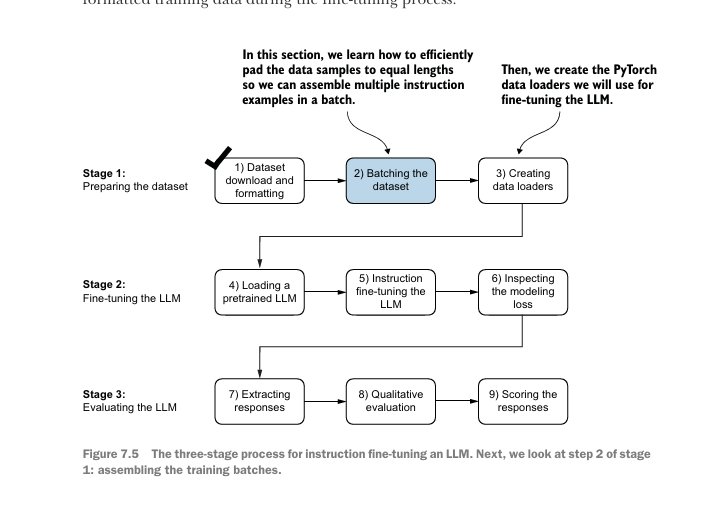

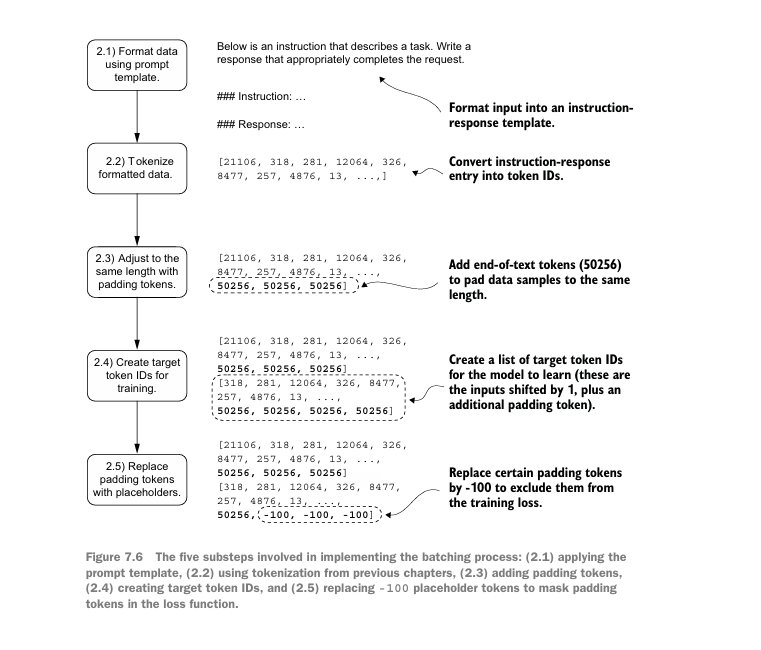

In [11]:
import torch
from torch.utils.data import Dataset

class InstructionDataset(Dataset): 
    def __init__(self, data, tokenizer):
        self.data = data
        self.encoded_texts = []
        for entry in data: 
            instruction_plus_input = format_input(entry)
            response_text = f"\n\n### Response:\n{entry['output']}"
            full_text = instruction_plus_input + response_text
            self.encoded_texts.append(
                tokenizer.encode(full_text)
            )
    def __getitem__(self,index): 
        return self.encoded_texts[index]
    def __len__(self): 
        return len(self.data)

In [12]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

[50256]


### Add padding

In [13]:
def custom_collate_draft_1(
    batch, pad_token_id = 50256, 
    device = "cpu"
): 
    batch_max_length = max(len(item)+1 for item in batch)
    inputs_lst = []
    for item in batch: 
        new_item = item.copy()
        new_item +=[pad_token_id]
        padded = (
            new_item + [pad_token_id]*(batch_max_length - len(new_item))
        )
        inputs = torch.tensor(padded[:-1])
        inputs_lst.append(inputs)
    inputs_tensor = torch.stack(inputs_lst).to(device)
    return inputs_tensor

In [14]:
inputs_1 = [0, 1, 2, 3, 4]
inputs_2 = [5, 6]
inputs_3 = [7, 8, 9]
batch = (
    inputs_1,
    inputs_2,
    inputs_3
)
print(custom_collate_draft_1(batch))

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])


In [15]:
def custom_collate_draft_2(
    batch, pad_token_id = 50256, device = "cpu"
): 
    batch_max_length=max(len(item)+1 for item in batch)
    inputs_lst , targets_lst = [],[]
    for item in batch: 
        new_item = item.copy()
        new_item +=[pad_token_id]
        padded = (
            new_item + [pad_token_id] * (batch_max_length - len(new_item))
        )
        inputs = torch.tensor(padded[:-1])
        targets = torch.tensor(padded[1:])
        inputs_lst.append(inputs)
        targets_lst.append(targets)
    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)
    return inputs_tensor, targets_tensor

inputs, targets = custom_collate_draft_2(batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256, 50256, 50256, 50256],
        [    8,     9, 50256, 50256, 50256]])


### Replace special token to -100
- Loss for meanningfull token , not forall

In [16]:
def custom_collate_fn(
    batch, pad_token_id = 50256, ignore_index = -100, allowed_max_length = None, device = "cpu"
): 
    batch_max_length = max(len(item)+1 for item in batch)
    inputs_lst, targets_lst = [],[]
    for item in batch: 
        new_item = item.copy()
        new_item+=[pad_token_id]

        padded = (
            new_item + [pad_token_id]* (batch_max_length - len(new_item))
        )
        inputs = torch.tensor(padded[:-1])
        targets = torch.tensor(padded[1:])
        mask = targets == pad_token_id
        indicies = torch.nonzero(mask).squeeze()
        if indicies.numel() > 1 : 
            targets[indicies[1:]] = ignore_index
        if allowed_max_length is not None: 
            inputs = inputs[:allowed_max_length]
            targets = targets[:allowed_max_length]
        inputs_lst.append(inputs)
        targets_lst.append(targets)
    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)
    return inputs_tensor, targets_tensor

In [17]:
inputs, targets = custom_collate_fn(batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256,  -100,  -100,  -100],
        [    8,     9, 50256,  -100,  -100]])


### why -100

In [18]:
logits_1 = torch.tensor(
    [[-1.0, 1.0], 
    [-0.5, 1.5]]
)
targets_1 = torch.tensor([0,1])
loss_1 = torch.nn.functional.cross_entropy(logits_1, targets_1)
print(loss_1)

tensor(1.1269)


In [19]:
logits_2 = torch.tensor(
    [[-1.0, 1.0],
     [-0.5, 1.5],
     [-0.5, 1.5]]     
)

targets_2 = torch.tensor([0, 1, 1])
loss_2 = torch.nn.functional.cross_entropy(logits_2, targets_2)
print(loss_2)

tensor(0.7936)


In [20]:
targets_3 = torch.tensor([0, 1, -100])
loss_3 = torch.nn.functional.cross_entropy(logits_2, targets_3)
print(loss_3)
print("loss_1 == loss_3:", loss_1 == loss_3)


tensor(1.1269)
loss_1 == loss_3: tensor(True)


### Creating dataloader

In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# if torch.backends.mps.is_available():  
#     device = torch.device("mps")"      
print("Device:", device)

Device: cuda


In [22]:
from functools import partial
customized_collate_fn = partial(
    custom_collate_fn, 
    device = device, 
    allowed_max_length = 1024
)

In [23]:
from torch.utils.data import DataLoader

num_workers = 0 
batch_size = 8
torch.manual_seed(123)

train_dataset = InstructionDataset(train_data, tokenizer)
train_loader = DataLoader(
    train_dataset, 
    batch_size = batch_size, 
    collate_fn = customized_collate_fn,
    shuffle = True, 
    drop_last = True, 
    num_workers = num_workers
)

val_dataset = InstructionDataset(val_data, tokenizer)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)
test_dataset = InstructionDataset(test_data, tokenizer)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

In [24]:
print("Train loader:")
for inputs, targets in train_loader:
    print(inputs.shape, targets.shape)

Train loader:
torch.Size([8, 62]) torch.Size([8, 62])
torch.Size([8, 77]) torch.Size([8, 77])
torch.Size([8, 74]) torch.Size([8, 74])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 66]) torch.Size([8, 66])
torch.Size([8, 73]) torch.Size([8, 73])
torch.Size([8, 81]) torch.Size([8, 81])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 63]) torch.Size([8, 63])
torch.Size([8, 76]) torch.Size([8, 76])
torch.Size([8, 63]) torch.Size([8, 63])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 78]) torch.Size([8, 78])
torch.Size([8, 70]) torch.Size([8, 70])
torch.Size([8, 80]) torch.Size([8, 80])
torch.Size([8, 72]) torch.Size([8, 72])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 84]) torch.Size([8, 84])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 81]) torch.Size([8, 81])
torch.Size([8, 72]) torch.Size([8, 72])
torch.Size([8, 70]) torch.Size([8, 70])
torch.Size([8, 66]) torch.Size([8, 66])
torch.Size([8, 69]) torch.

## Download model 

In [25]:
pip install transformers

Note: you may need to restart the kernel to use updated packages.


In [26]:
BASE_CONFIG = {
    "vocab_size": 50257,     # Vocabulary size
    "context_length": 1024,  # Context length
    "drop_rate": 0.0,        # Dropout rate
    "qkv_bias": True,         # Query-key-value bias
    "emb_dim":768
}

In [27]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer

model_name = "gpt2-medium"

tokenizer = GPT2Tokenizer.from_pretrained(model_name)
model = GPT2LMHeadModel.from_pretrained(model_name)

model.eval()

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/718 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.52G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2-medium
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...23}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 1024)
    (wpe): Embedding(1024, 1024)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-23): 24 x GPT2Block(
        (ln_1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=3072, nx=1024)
          (c_proj): Conv1D(nf=1024, nx=1024)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=4096, nx=1024)
          (c_proj): Conv1D(nf=1024, nx=4096)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=1024, out_features=50257, bias=False)
)

In [28]:
torch.manual_seed(123)
input_text = format_input(val_data[0])
print(input_text)

Below is an instruction that describes a task. Write a response that appropriately completes the request. 

### Instruction:
Convert the active sentence to passive: 'The chef cooks the meal every day.'


In [29]:
text = "Hoang ha is"

inputs = tokenizer(text, return_tensors="pt")

outputs = model.generate(
    **inputs,
    max_new_tokens=30
)

print(tokenizer.decode(outputs[0], skip_special_tokens=True))

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Hoang ha is a very good player, but he's not a great player. He's not a great player. He's not a great player. He's not


In [30]:
inputs = tokenizer(input_text, return_tensors="pt")
outputs = model.generate(
    **inputs,
    max_new_tokens=35
)

generated_text = (tokenizer.decode(outputs[0], skip_special_tokens=True))
print(generated_text)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Below is an instruction that describes a task. Write a response that appropriately completes the request. 

### Instruction:
Convert the active sentence to passive: 'The chef cooks the meal every day.'

### Response:

The chef cooks the meal every day.

### Instruction:

Convert the active sentence to passive: 'The chef cooks the


In [31]:
response_text = generated_text[len(input_text):].strip()
print(response_text)


### Response:

The chef cooks the meal every day.

### Instruction:

Convert the active sentence to passive: 'The chef cooks the


## Fine tuning the LLM 

In [32]:
def calc_loss_batch(input_batch, target_batch, model, device): 
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)

    outputs = model(input_batch)
    logits = outputs.logits

    loss = torch.nn.functional.cross_entropy(
        logits.flatten(0, 1),
        target_batch.flatten()
    )

    return loss

In [33]:
def calc_loss_loader(data_loader, model, device, num_batches=None): 
    total_loss = 0

    if len(data_loader) == 0: 
        return float("nan")

    if num_batches is None:
        num_batches = len(data_loader)
    else: 
        num_batches = min(num_batches, len(data_loader))

    for i, (input_batch, target_batch) in enumerate(data_loader): 
        if i < num_batches: 
            loss = calc_loss_batch(
                input_batch, target_batch, model, device
            )
            total_loss += loss.item()
        else:
            break

    return total_loss / num_batches

In [34]:
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs, eval_freq, eval_iter, start_context, tokenizer): 
    train_losses, val_losses, track_tokens_seen =[],[],[]
    tokens_seen, global_step =0,-1
    for epoch in range(num_epochs): 
        model.train()
        for input_batch,target_batch in train_loader: 
            optimizer.zero_grad()
            loss = calc_loss_batch(
                input_batch,target_batch,model,device
            )
            loss.backward()
            optimizer.step()
            tokens_seen += input_batch.numel()
            global_step+=1
            if global_step % eval_freq ==0: 
                train_loss, val_loss = evaluate_model(
                    model, train_loader,val_loader, device,eval_iter
                )
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                          f"Train loss {train_loss:.3f}, "
                          f"Val loss {val_loss:.3f}"
                )

        generate_and_print_sample(
            model,tokenizer, device, start_context
        )

    return train_losses, val_losses, track_tokens_seen

def evaluate_model(model, train_loader, val_loader, device, eval_iter): 
    model.eval()
    with torch.no_grad(): 
        train_loss= calc_loss_loader(
            train_loader, model, device, num_batches = eval_iter
        )
        val_loss = calc_loss_loader(
            val_loader, model, device , num_batches = eval_iter
        )
    model.train()
    return train_loss, val_loss

def generate_and_print_sample(model, tokenizer, device, start_context): 
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad(): 
        token_ids = generate_text_simple(
            model=model, idx=encoded, max_new_tokens=50, context_size = context_size
        )

    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n"," "))
    model.train()

In [35]:
model.to(device)
torch.manual_seed(123)

with torch.no_grad():
    train_loss = calc_loss_loader(
        train_loader, model, device, num_batches=5
    )
    val_loss = calc_loss_loader(
        val_loader, model, device, num_batches=5
    )

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 3.9499627590179442
Validation loss: 3.8900279998779297


In [36]:
def generate_and_print_sample(model, tokenizer, device, start_context): 
    model.eval()

    encoded = tokenizer(
        start_context,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad(): 
        output_ids = model.generate(
            **encoded,
            max_new_tokens=50,
            pad_token_id=tokenizer.eos_token_id
        )

    decoded_text = tokenizer.decode(
        output_ids[0],
        skip_special_tokens=True
    )

    response_text = decoded_text[len(start_context):].strip()

    print(response_text.replace("\n", " "))

    model.train()

In [37]:
import time

start_time = time.time()
torch.manual_seed(123)

optimizer = torch.optim.AdamW(
    model.parameters(), lr=0.00005, weight_decay=0.1
)

num_epochs = 2

train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context=format_input(val_data[0]), tokenizer=tokenizer
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60

print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 2.652, Val loss 2.639
Ep 1 (Step 000005): Train loss 1.163, Val loss 1.100
Ep 1 (Step 000010): Train loss 0.860, Val loss 0.961
Ep 1 (Step 000015): Train loss 0.863, Val loss 0.918
Ep 1 (Step 000020): Train loss 0.799, Val loss 0.903
Ep 1 (Step 000025): Train loss 0.762, Val loss 0.872
Ep 1 (Step 000030): Train loss 0.815, Val loss 0.859
Ep 1 (Step 000035): Train loss 0.735, Val loss 0.830
Ep 1 (Step 000040): Train loss 0.701, Val loss 0.823
Ep 1 (Step 000045): Train loss 0.655, Val loss 0.816
Ep 1 (Step 000050): Train loss 0.708, Val loss 0.803
Ep 1 (Step 000055): Train loss 0.780, Val loss 0.792
Ep 1 (Step 000060): Train loss 0.740, Val loss 0.771
Ep 1 (Step 000065): Train loss 0.667, Val loss 0.752
Ep 1 (Step 000070): Train loss 0.570, Val loss 0.742
Ep 1 (Step 000075): Train loss 0.580, Val loss 0.741
Ep 1 (Step 000080): Train loss 0.641, Val loss 0.736
Ep 1 (Step 000085): Train loss 0.537, Val loss 0.728
Ep 1 (Step 000090): Train loss 0.586, Val loss

In [38]:
inputs = tokenizer(input_text, return_tensors="pt").to(device)

outputs = model.generate(
    **inputs,
    max_new_tokens=35,
    pad_token_id=tokenizer.eos_token_id
)

generated_text = tokenizer.decode(
    outputs[0],
    skip_special_tokens=True
)

print(generated_text)

Below is an instruction that describes a task. Write a response that appropriately completes the request. 

### Instruction:
Convert the active sentence to passive: 'The chef cooks the meal every day.'

### Response:
The meal is cooked every day by the chef.


In [39]:
import tiktoken
def text_to_token_ids(text,tokenizer): 
    encoded = tokenizer.encode(text,allowed_special = {'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer): 
    flat = token_ids.squeeze(0)
    return tokenizer.decode(flat.tolist())

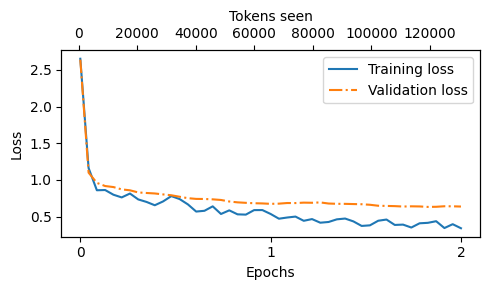

In [40]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses): 
    fig, ax1 = plt.subplots(figsize=(5, 3))
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(
        epochs_seen, val_losses, linestyle="-.", label="Validation loss"
    )
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax2 = ax1.twiny()                  
    ax2.plot(tokens_seen, train_losses, alpha=0)    
    ax2.set_xlabel("Tokens seen")
    fig.tight_layout()
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

## Extracting and saving respone

In [41]:
torch.manual_seed(123)

model.eval()

for entry in test_data[:3]: 
    input_text = format_input(entry)
    # prompt = input_text + "\n\n### Response:\n"
    prompt = input_text 

    inputs = tokenizer(
        prompt,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=256,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.eos_token_id
        )

    generated_text = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    response_text = generated_text[len(prompt):].strip()

    print(input_text)
    print(f"\nCorrect response:\n>> {entry['output']}")
    print(f"\nModel response:\n>> {response_text}")
    print("-------------------------------------")

Below is an instruction that describes a task. Write a response that appropriately completes the request. 

### Instruction:
Rewrite the sentence using a simile.

### Input:
The car is very fast.

Correct response:
>> The car is as fast as lightning.

Model response:
>> ### Response:
The car is as fast as a bullet.
-------------------------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request. 

### Instruction:
What type of cloud is typically associated with thunderstorms?

Correct response:
>> The type of cloud typically associated with thunderstorms is cumulonimbus.

Model response:
>> ### Response:
A thunderstorm is a type of cumulus or cumulus-capped cumulus.
-------------------------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request. 

### Instruction:
Name the author of 'Pride and Prejudice'.

Correct response:
>> Jane Austen.

Model response:
>> ###

In [42]:
torch.manual_seed(123)

model.eval()

for entry in val_data[:3]: 
    input_text = format_input(entry)
    prompt = input_text + "\n\n### Response:\n"

    inputs = tokenizer(
        prompt,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=256,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.eos_token_id
        )

    generated_text = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    response_text = generated_text[len(prompt):].strip()

    print(input_text)
    print(f"\nCorrect response:\n>> {entry['output']}")
    print(f"\nModel response:\n>> {response_text}")
    print("-------------------------------------")

Below is an instruction that describes a task. Write a response that appropriately completes the request. 

### Instruction:
Convert the active sentence to passive: 'The chef cooks the meal every day.'

Correct response:
>> The meal is cooked by the chef every day.

Model response:
>> The meal is cooked every day by the chef.
-------------------------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request. 

### Instruction:
Classify an input string as either a noun or a verb.

### Input:
Dance

Correct response:
>> 'Dance' can be classified as a verb.

Model response:
>> Dance is a verb.
-------------------------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request. 

### Instruction:
Rewrite the sentence using a metaphor.

### Input:
The book is very interesting.

Correct response:
>> The book is a page-turner.

Model response:
>> The book is a book.
---------

In [43]:
from tqdm import tqdm

for i, entry in tqdm(enumerate(test_data), total=len(test_data)): 
    input_text = format_input(entry)
    prompt = input_text

    inputs = tokenizer(
        prompt,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        token_ids = model.generate(
            **inputs,
            max_new_tokens=256,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.eos_token_id
        )
    generated_text = tokenizer.decode(
        token_ids[0],
        skip_special_tokens=True
    )
    response_text = generated_text[len(prompt):].replace("### Response:", "").strip()
    test_data[i]["model_response"] = response_text
with open("instruction-data-with-response.json", "w") as file:
    json.dump(test_data, file, indent=4) 

100%|██████████| 110/110 [00:40<00:00,  2.73it/s]


In [44]:
print(test_data[0])

{'instruction': 'Rewrite the sentence using a simile.', 'input': 'The car is very fast.', 'output': 'The car is as fast as lightning.', 'model_response': 'The car is as fast as a bullet.'}


In [45]:
import re 
file_name = "GPTModel_finetune"   
torch.save(model.state_dict(), file_name)
print(f"Model saved as {file_name}")

Model saved as GPTModel_finetune


## Evaluating the fine-tuned LLM 
### use API model evluate

In [115]:
import json
import os
import re
import urllib.request
from tqdm import tqdm
from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()
GEMINI_API_KEY = user_secrets.get_secret("GEMINI_API_KEY")

# Doi model o day neu model hien tai bi qua tai.
GEMINI_MODEL = "gemini-2.5-flash"
GEMINI_URL = (
    f"https://generativelanguage.googleapis.com/v1beta/models/"
    f"{GEMINI_MODEL}:generateContent?key={GEMINI_API_KEY}"
)

In [116]:
def extract_text_from_gemini_response(response_json):
    try:
        return response_json["candidates"][0]["content"]["parts"][0]["text"]
    except (KeyError, IndexError, TypeError):
        print("Unexpected Gemini response JSON:")
        print(json.dumps(response_json, indent=2, ensure_ascii=False)[:3000])
        raise


def query_model(prompt, url=GEMINI_URL, max_retries=5):
    data = {
        "contents": [
            {
                "parts": [
                    {"text": prompt}
                ]
            }
        ],
        "generationConfig": {
            "temperature": 0
        }
    }

    payload = json.dumps(data).encode("utf-8")

    for attempt in range(max_retries):
        request = urllib.request.Request(
            url,
            data=payload,
            method="POST"
        )
        request.add_header("Content-Type", "application/json")

        try:
            with urllib.request.urlopen(request) as response:
                response_data = response.read().decode("utf-8")

            response_json = json.loads(response_data)
            return extract_text_from_gemini_response(response_json)

        except urllib.error.HTTPError as e:
            error_text = e.read().decode("utf-8")
            print("HTTP status:", e.code)
            print("API error:", error_text)

            if e.code in [429, 500, 503] and attempt < max_retries - 1:
                wait_time = 10 * (attempt + 1)
                print(f"Waiting {wait_time} seconds before retry...")
                time.sleep(wait_time)
                continue

            raise

    raise RuntimeError("Gemini API failed after multiple retries.")

In [117]:
def build_eval_prompt(entry, json_key="model_response"):
    return (
        f"Given the input `{format_input(entry)}` "
        f"and correct output `{entry['output']}`, "
        f"score the model response `{entry[json_key]}` "
        f"on a scale from 0 to 100, where 100 is the best score. "
        f"Respond with the integer number only."
    )


def extract_integer_score(score_text):
    match = re.search(r"\d+", score_text)

    if match is None:
        raise ValueError(f"Could not convert score: {score_text}")

    score = int(match.group())
    return max(0, min(100, score))

In [118]:
for entry in test_data[:3]:
    prompt = build_eval_prompt(entry, json_key="model_response")
    raw_score = query_model(prompt)
    score = extract_integer_score(raw_score)

    print("\nDataset response:")
    print(">>", entry["output"])

    print("\nModel response:")
    print(">>", entry["model_response"])

    print("\nScore:")
    print(">>", score)

    print("\n-------------------------")

HTTP status: 503
API error: {
  "error": {
    "code": 503,
    "message": "This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.",
    "status": "UNAVAILABLE"
  }
}

Waiting 10 seconds before retry...

Dataset response:
>> The car is as fast as lightning.

Model response:
>> The car is as fast as a bullet.

Score:
>> 100

-------------------------

Dataset response:
>> The type of cloud typically associated with thunderstorms is cumulonimbus.

Model response:
>> A thunderstorm is a type of cumulus or cumulus-capped cumulus.

Score:
>> 0

-------------------------

Dataset response:
>> Jane Austen.

Model response:
>> The author of 'Pride and Prejudice' is George Eliot.

Score:
>> 0

-------------------------


In [119]:
def generate_model_scores(json_data, json_key="model_response"):
    scores = []

    for entry in tqdm(json_data, desc="Scoring entries"):
        prompt = build_eval_prompt(entry, json_key=json_key)
        raw_score = query_model(prompt)

        try:
            score = extract_integer_score(raw_score)
        except ValueError:
            print(f"Could not convert score: {raw_score}")
            continue

        entry["api_score"] = score
        entry["api_raw_score"] = raw_score
        scores.append(score)

    return scores

In [124]:
# Test nhanh voi 5 mau. Khi on roi, doi test_data[:5] thanh test_data de cham toan bo.
scores = generate_model_scores(test_data[:20], json_key="model_response")

print("Number of scores:", len(scores))
print(f"Average score: {sum(scores) / len(scores):.2f}")

Scoring entries:   0%|          | 0/20 [00:00<?, ?it/s]

HTTP status: 429
API error: {
  "error": {
    "code": 429,
    "message": "You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash\nPlease retry in 3.343687194s.",
    "status": "RESOURCE_EXHAUSTED",
    "details": [
      {
        "@type": "type.googleapis.com/google.rpc.Help",
        "links": [
          {
            "description": "Learn more about Gemini API quotas",
            "url": "https://ai.google.dev/gemini-api/docs/rate-limits"
          }
        ]
      },
      {
        "@type": "type.googleapis.com/google.rpc.QuotaFailure",
        "violations": [
          {
            "quotaMetric": "generativelanguage.googleapis.com/generate_content_free_tier_re

Scoring entries:   0%|          | 0/20 [01:17<?, ?it/s]


KeyboardInterrupt: 

In [122]:
output_file = "instruction-data-with-api-scores.json"

with open(output_file, "w", encoding="utf-8") as file:
    json.dump(test_data, file, indent=4, ensure_ascii=False)

print("Saved to:", output_file)

Saved to: instruction-data-with-api-scores.json
